In [1]:
import numpy as np
from mesoscopy.resources import get_atlas, get_atlas_annotations
import matplotlib.pyplot as plt
from mesoscopy import io
from mesoscopy.process import region


In [2]:
f = io.read_h5("../scratch/sub-test_exp-testexp_meso_date-2025-05-20T14_42_39_preprocessed_registered.h5")

In [3]:
l_aba, r_aba = get_atlas()

In [4]:
l_aba

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(140, 142), dtype=uint16)

In [5]:
mask = np.broadcast_to(l_aba == 578, f["F"].shape)

np.ma.array(f["F"], mask=~mask)

masked_array(
  data=[[[--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         ...,
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --]],

        [[--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         ...,
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --]],

        [[--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         ...,
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --]],

        ...,

        [[--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         ...,
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --,

In [6]:
annotations = get_atlas_annotations()
annotations

,id,acronym,name
0,11,SSp-ul,Primary somatosensory area upper limb
1,97,AUDd1,Dorsal auditory area
2,104,AUDp1,Primary auditory area
3,111,AUDpo1,Posterior auditory area
4,118,AUDv1,Ventral auditory area
5,395,FRP1,Frontal pole
6,578,MOp1,Primary motor area
7,584,MOs,Secondary motor area
8,665,ORBm1,Orbital area medial part
9,753,PL1,Prelimbic area


In [7]:
annotations.loc[annotations["acronym"] == "VISli1", "id"].values[0]

np.int64(1214)

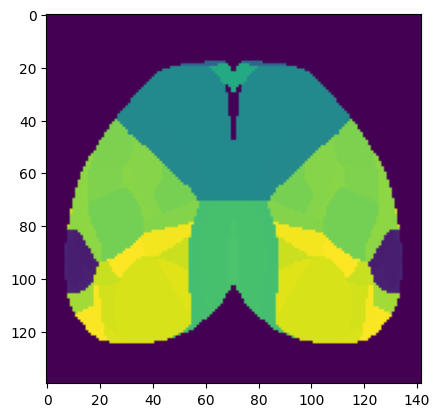

In [8]:
plt.imshow(l_aba + r_aba)

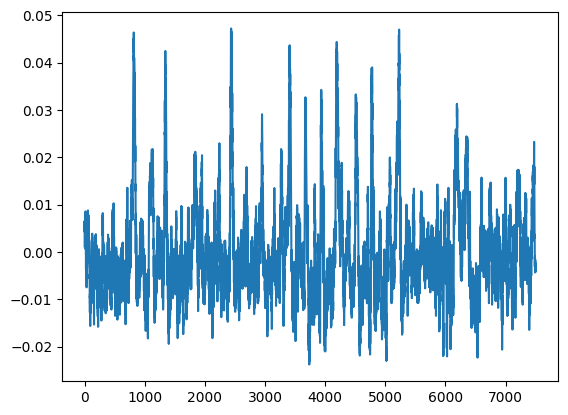

In [9]:
plt.plot(np.ma.array(f["F"], mask=~mask).mean(axis=(1, 2)))

In [10]:
get_atlas_annotations().acronym.unique()

array(['SSp-ul', 'AUDd1', 'AUDp1', 'AUDpo1', 'AUDv1', 'FRP1', 'MOp1',
       'MOs', 'ORBm1', 'PL1', 'RSPagl1', 'RSPd1', 'RSPv1', 'SSp-bfd1',
       'SSp-ll1', 'SSp-m1', 'SSp-n1', 'SSp-tr1', 'SSp-ul1', 'SSp-un1',
       'SSs1', 'TEa1', 'VISal1', 'VISam1', 'VISC1', 'VISl1', 'VISp',
       'VISpl1', 'VISpm', 'VISa1', 'VISli1', 'VISpor1', 'VISrl1'],
      dtype=object)

In [11]:
region_activity = region.extract_all_regions(deltaf_series=f["F"])

In [12]:
region_activity

{'L_SSp-ul': masked_array(data=[-0.014033851213753223, -0.0023055514320731163,
                    -0.0046494812704622746, ..., -0.005773003213107586,
                    -0.006918411236256361, 0.003909487742930651],
              mask=[False, False, False, ..., False, False, False],
        fill_value=1e+20),
 'R_SSp-ul': masked_array(data=[0.0011805910617113113, -0.004940943326801062,
                    -0.004747333005070686, ..., 0.005206792615354061,
                    -0.003380958689376712, -0.002345480490475893],
              mask=[False, False, False, ..., False, False, False],
        fill_value=1e+20),
 'L_MOp1': masked_array(data=[0.0012087095742938161, 0.006479873511069579,
                    0.004268450755269135, ..., -0.002622898511046194,
                    -0.004218819497645587, -0.0018279879029226486],
              mask=[False, False, False, ..., False, False, False],
        fill_value=1e+20),
 'R_MOp1': masked_array(data=[-1.5095275937369044e-07, 0.0031936260018

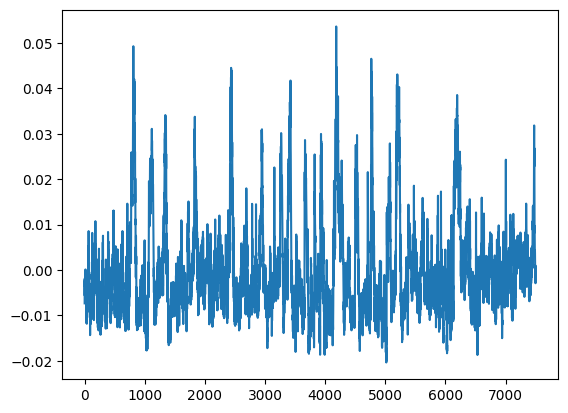

In [13]:
plt.plot(region_activity["L_MOs"])

In [16]:
import pandas as pd


In [79]:
df = pd.DataFrame(region_activity)

In [101]:
df.unstack()

L_SSp-ul  0      -0.014034
          1      -0.002306
          2      -0.004649
          3      -0.005122
          4      -0.013291
                    ...   
R_VISrl1  7495    0.000298
          7496   -0.000169
          7497   -0.000756
          7498   -0.002265
          7499   -0.002328
Length: 345000, dtype: float64